# Imports & Set up

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Carga de Datos

In [5]:
df = pd.read_csv("../data/raw/cs-training.csv")

# delete index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Vista Previa de los Datos

In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


# Variable Objetivo

In [7]:
target = "SeriousDlqin2yrs"

df[target].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

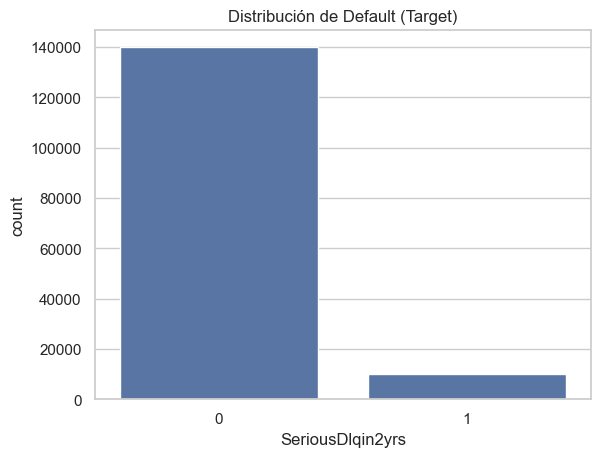

In [8]:
sns.countplot(x=df[target])
plt.title("Distribución de Default (Target)")
plt.show()

* El dataset presenta un marcado desbalance de clases, donde los casos de incumplimiento representan una proporción significativamente menor.
* Esta característica implica la necesidad de aplicar técnicas específicas durante el modelado, como el ajuste de pesos de clase o métodos de remuestreo, para evitar sesgos en las predicciones.

# Variables Nulas

In [9]:
df.isnull().sum().sort_values(ascending=False)

MonthlyIncome                           29731
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
age                                         0
RevolvingUtilizationOfUnsecuredLines        0
DebtRatio                                   0
NumberOfTime30-59DaysPastDueNotWorse        0
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
dtype: int64

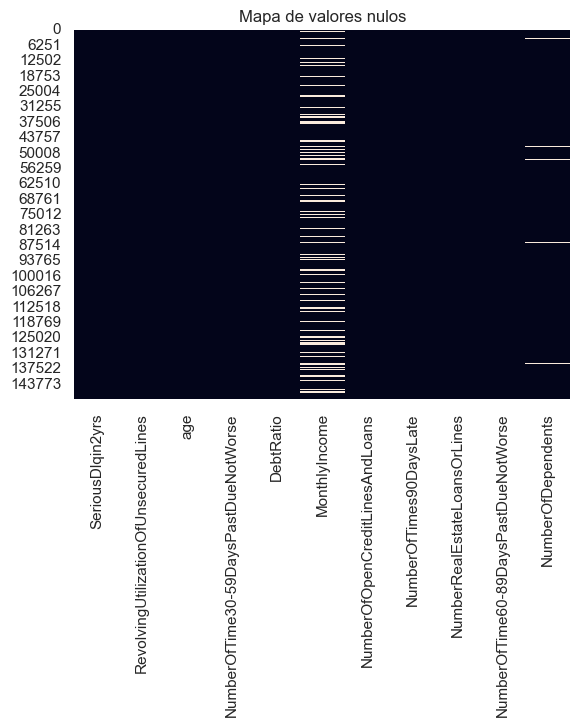

In [10]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

## Análisis de Valores Nulos

El dataset contiene valores faltantes principalmente en dos variables:

- **MonthlyIncome (20% de valores faltantes)**  
- **NumberOfDependents (2-3% de valores faltantes)**  

### Observaciones clave

- `NumberOfDependents` presenta pocos valores faltantes y puede imputarse razonablemente con 0, asumiendo ausencia de dependientes o valores no reportados.
  
- `MonthlyIncome` presenta una proporción significativa de valores faltantes. Debido a su distribución sesgada y la presencia de outliers, es preferible utilizar la mediana en lugar de la media para la imputación.

- Los valores faltantes en `MonthlyIncome` no parecen ser completamente aleatorios, lo que sugiere que la ausencia de datos podría constituir una señal predictiva en sí misma.

### Consideraciones para el modelado

- Las estrategias de imputación deben aplicarse cuidadosamente durante el entrenamiento del modelo para evitar fuga de información (ajustándose únicamente sobre el conjunto de entrenamiento).

# Variables Numéricas

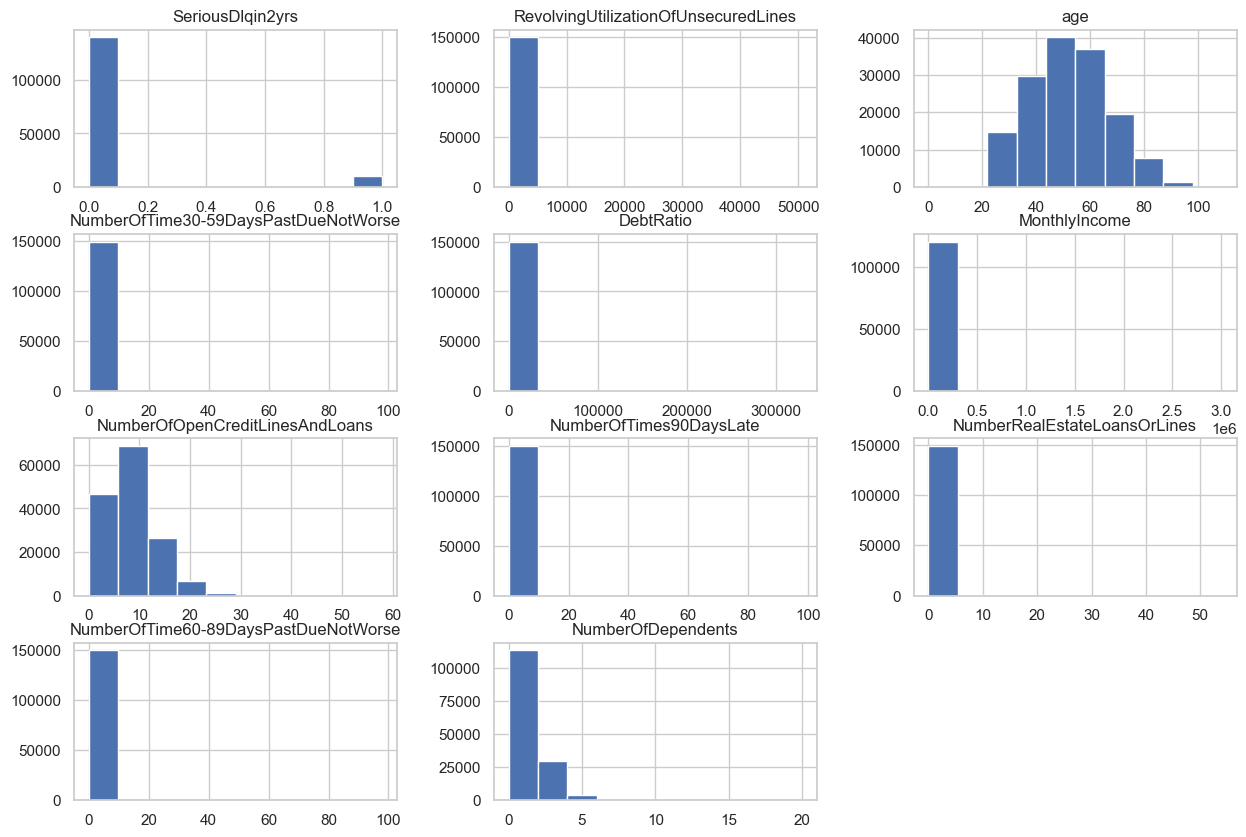

In [11]:
df.hist(figsize=(15,10))
plt.show()

## Análisis de Variables Numéricas

A partir del análisis de las variables numéricas se identifican varios patrones relevantes:

- El dataset presenta un alto desbalance de clases, con muy pocos casos de incumplimiento (default).
- Múltiples variables contienen outliers extremos, particularmente:
  - `RevolvingUtilizationOfUnsecuredLines`
  - `DebtRatio`
  - Variables relacionadas con atrasos (delinquency)
- Estos valores extremos no son realistas y probablemente corresponden a problemas de calidad de datos o casos atípicos (edge cases).
- Las variables relacionadas con ingresos presentan una alta asimetría (skewness) y podrían requerir transformaciones (por ejemplo, escala logarítmica).
- La variable `age` muestra una distribución adecuada y podría ser útil para la predicción.
- Las variables de atraso se perfilan como fuertes predictoras, aunque requieren limpieza debido a valores no realistas.

## Implicación clave

El preprocesamiento de los datos será crítico antes del modelado, especialmente en aspectos como:

- Tratamiento de outliers (capping o transformación)
- Escalamiento de variables
- Manejo de distribuciones sesgadas

# Análisis de Variables Claves

## Debt Ratio

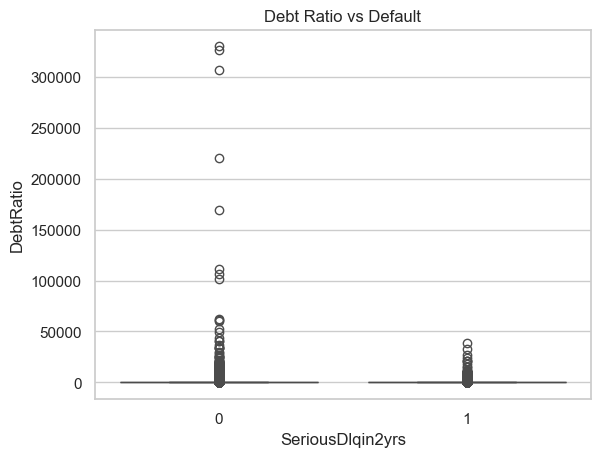

In [12]:
sns.boxplot(x=df[target], y=df["DebtRatio"])
plt.title("Debt Ratio vs Default")
plt.show()

### Análisis de DebtRatio

La variable `DebtRatio` presenta una distribución extremadamente sesgada, con varios outliers no realistas que alcanzan valores superiores a 300,000.

### Observaciones clave:

- La mayoría de los valores se concentran cerca de cero
- Existen outliers extremos en ambas clases (default y no default)
- Estos valores extremos no aportan una separación significativa entre las clases

### Interpretación:

Estos valores extremos probablemente se deben a problemas de calidad de datos o a divisiones entre ingresos muy bajos o cercanos a cero.

### Implicación para el modelado:

Será necesario aplicar técnicas de tratamiento de outliers (por ejemplo, capping o transformaciones) para mejorar la estabilidad y el rendimiento del modelo.

## Age

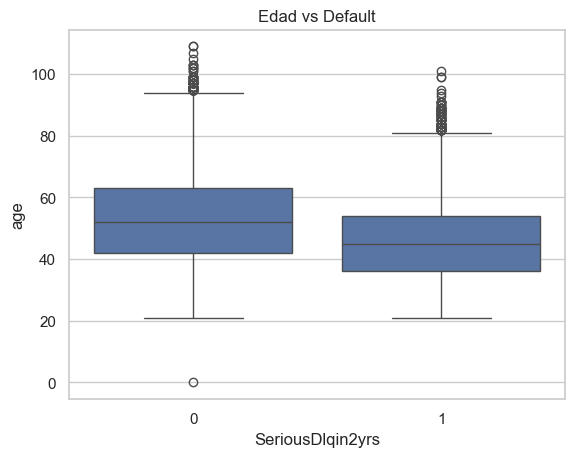

In [13]:
sns.boxplot(x=df[target], y=df["age"])
plt.title("Edad vs Default")
plt.show()

### Análisis de la variable Age

La distribución de la variable `age` muestra una diferencia notable entre clientes en default y no default:

- Los clientes que presentan incumplimiento tienden a ser más jóvenes en promedio
- Los clientes sin incumplimiento se concentran en rangos de mayor edad (45–65)

Sin embargo, existe un solapamiento significativo entre ambos grupos, lo que indica que la edad por sí sola no es un predictor fuerte, pero sí contribuye como una variable de apoyo.

### Calidad de datos

Se identificaron valores no realistas:
- Edades iguales a 0 o superiores a 100

Estos casos deberán ser tratados durante la fase de preprocesamiento.

## Montly Income

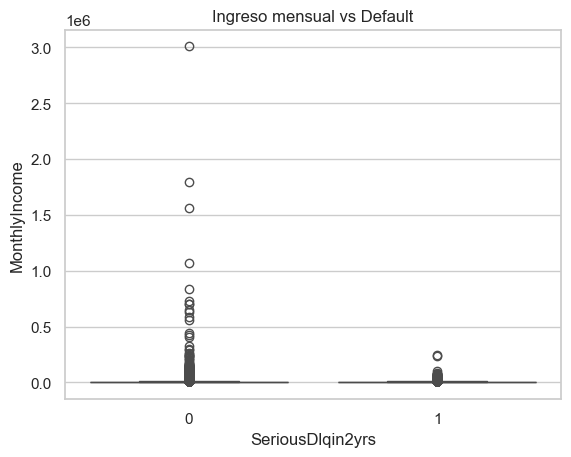

In [14]:
sns.boxplot(x=df[target], y=df["MonthlyIncome"])
plt.title("Ingreso mensual vs Default")
plt.show()

### Análisis de la variable MonthlyIncome

La variable `MonthlyIncome` presenta varios desafíos relevantes:

- La distribución es altamente sesgada, con la presencia de outliers extremos
- Existe una proporción significativa de valores faltantes (~20%)
- No se observa una separación clara entre las clases de default y no default

Adicionalmente, los valores extremos en `DebtRatio` probablemente están influenciados por ingresos muy bajos o faltantes.

### Implicaciones:

- Se recomienda la imputación utilizando la mediana, debido a la asimetría de la distribución
- Es necesario aplicar técnicas de capping para controlar los outliers y estabilizar la variable
- Una transformación logarítmica podría mejorar el rendimiento del modelo

#  Correlación de Variables

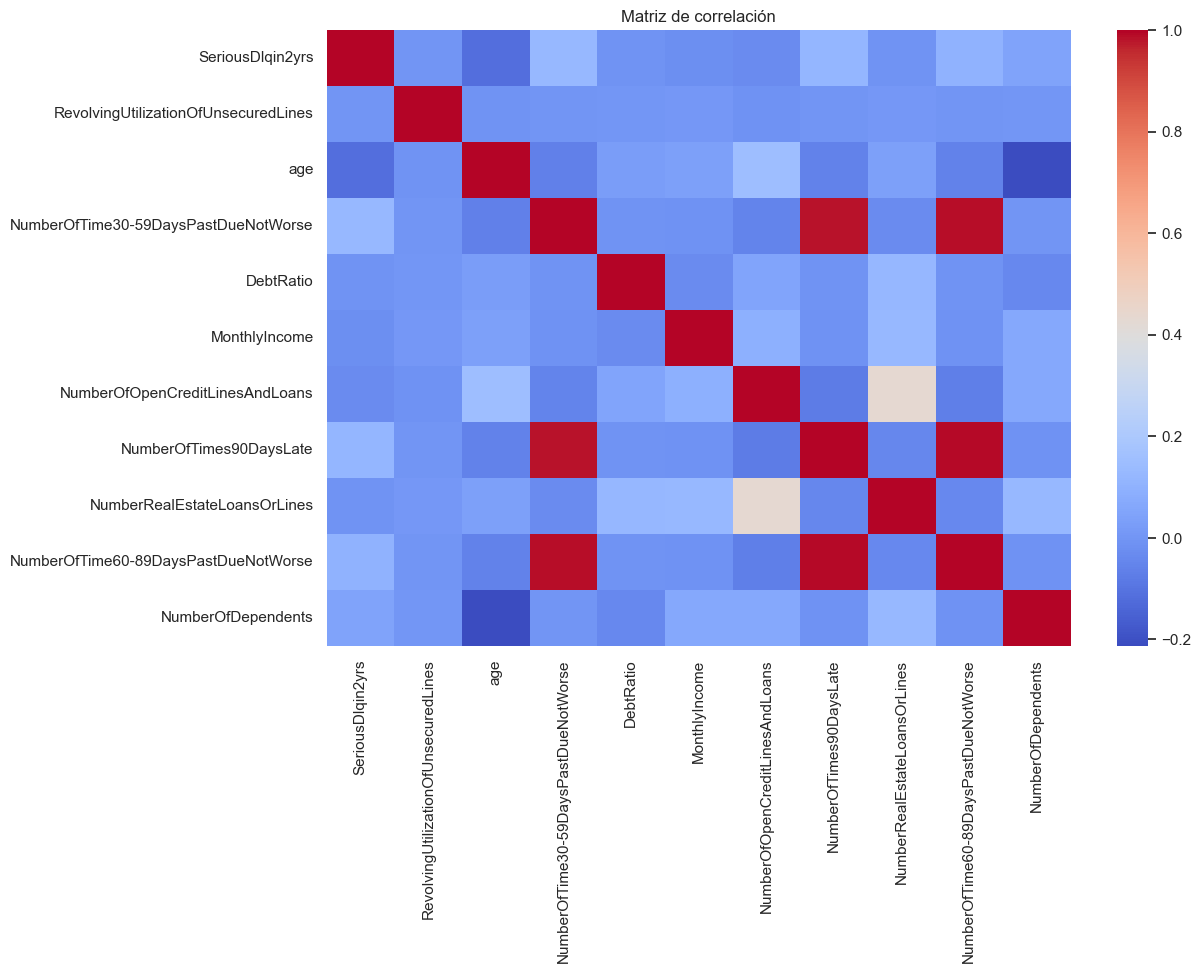

In [15]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

### Análisis de Correlación

La matriz de correlación revela varios patrones relevantes:

#### Hallazgos clave:

- Las variables relacionadas con atrasos (30-59, 60-89 y 90 días en mora) presentan la mayor correlación con la variable objetivo.
- Estas variables también están altamente correlacionadas entre sí, lo que indica posible multicolinealidad y redundancia.
- Indicadores financieros tradicionales como `MonthlyIncome` y `DebtRatio` muestran una débil correlación lineal con el default.
- La variable `age` presenta una ligera correlación negativa con el default, lo que sugiere que los individuos más jóvenes podrían tener mayor riesgo.
- Las variables de exposición crediticia (por ejemplo, número de líneas de crédito y préstamos inmobiliarios) muestran una correlación moderada entre sí.

#### Implicaciones:

- El comportamiento histórico de pago (atrasos) es el predictor más fuerte del incumplimiento futuro.
- Puede ser necesario aplicar técnicas de selección o ingeniería de variables para manejar la multicolinealidad entre variables de atraso.
- Una baja correlación no implica necesariamente bajo poder predictivo, especialmente en modelos no lineales.

# Outliers

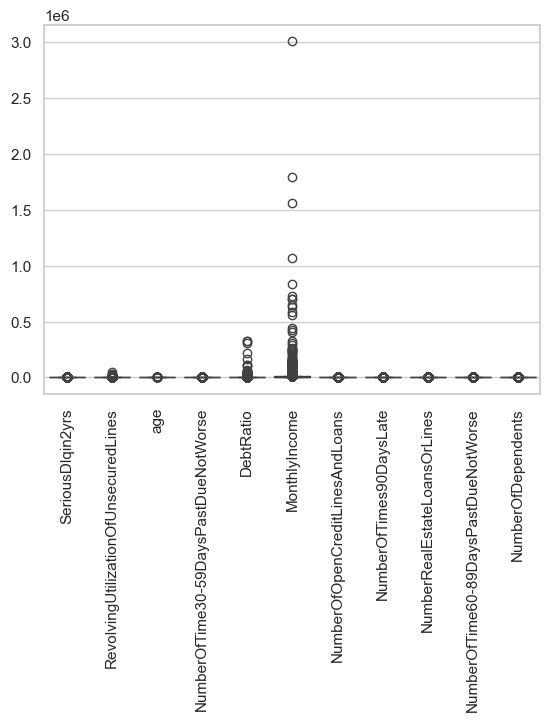

In [16]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

### Análisis de Outliers

El dataset presenta outliers significativos en múltiples variables, particularmente en:

- `MonthlyIncome`
- `DebtRatio`
- `RevolvingUtilizationOfUnsecuredLines`

Estos valores extremos suelen ser no realistas y no representan un comportamiento financiero consistente, lo que sugiere posibles problemas de calidad de datos.

#### Observaciones clave:

- Varias variables presentan una fuerte asimetría hacia la derecha (right skew)
- Los valores extremos dominan las distribuciones
- Las variables de atraso contienen conteos no realistas

#### Implicaciones:

- El tratamiento de outliers es esencial antes del modelado
- Se aplicarán técnicas como capping, transformaciones y reglas de validación
- No se recomienda eliminar filas de forma masiva, para evitar pérdida de información

# Conclusiones Finales del EDA

El análisis exploratorio de datos permitió identificar varios insights clave sobre el dataset y el problema de riesgo crediticio:

## 1. Desbalance de Clases
La variable objetivo (`SeriousDlqin2yrs`) presenta un alto desbalance, con una proporción reducida de casos de incumplimiento (default).

**Implicación:**
Será necesario aplicar técnicas específicas durante el modelado, como el ajuste de pesos de clase o métodos de remuestreo.

---

## 2. Problemas de Calidad de Datos
Varias variables contienen valores faltantes y outliers extremos:

- `MonthlyIncome` presenta aproximadamente un 20% de valores faltantes
- `NumberOfDependents` presenta una baja proporción de valores faltantes
- Múltiples variables contienen valores extremos no realistas

**Implicación:**
El preprocesamiento de datos será crítico, incluyendo imputación y tratamiento de outliers.

---

## 3. Outliers y Asimetría
Muchas variables numéricas presentan alta asimetría y valores extremos:

- `MonthlyIncome`, `DebtRatio` y `RevolvingUtilizationOfUnsecuredLines` contienen valores no consistentes con un comportamiento financiero plausible
- Las variables de atraso presentan conteos extremos (por ejemplo, valores cercanos a 100)

**Implicación:**
Será necesario aplicar técnicas como capping y transformaciones (por ejemplo, logarítmicas) para estabilizar las variables.

---

## 4. Señales Predictivas Fuertes
Las variables relacionadas con atrasos presentan la mayor correlación con el default:

- `NumberOfTime30-59DaysPastDueNotWorse`
- `NumberOfTimes90DaysLate`
- `NumberOfTime60-89DaysPastDueNotWorse`

**Implicación:**
El comportamiento histórico de pago es el principal indicador del riesgo de incumplimiento futuro.

---

## 5. Relaciones Lineales Débiles
Variables financieras tradicionales como `MonthlyIncome` y `DebtRatio` presentan una débil correlación lineal con la variable objetivo.

**Implicación:**
Modelos no lineales (por ejemplo, basados en árboles) podrían capturar mejor las relaciones en los datos.

---

## 6. Relaciones entre Variables
Existe una alta correlación entre las variables de atraso, lo que indica redundancia.

**Implicación:**
Será necesario aplicar técnicas de selección o ingeniería de variables para manejar la multicolinealidad.

---

## 7. Edad como Variable Complementaria
Los clientes más jóvenes presentan una mayor probabilidad de incumplimiento.

**Implicación:**
La edad aporta información relevante, aunque no es un predictor dominante.

---

## Conclusión General

El dataset representa un problema de riesgo crediticio realista y desafiante, caracterizado por:

- Desbalance de clases
- Presencia de valores faltantes
- Outliers significativos
- Fuertes variables de comportamiento (atrasos)

Será fundamental construir un pipeline robusto de preprocesamiento y aplicar técnicas adecuadas de ingeniería de variables antes de entrenar modelos de machine learning.

El siguiente paso consiste en implementar un pipeline de limpieza y transformación de datos que prepare el dataset para el modelado.